# Initializing

In [1]:
pip install scikit-learn==1.7.1


   ---------------------------------------- 0.0/8.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.9 MB ? eta -:--:--
   --------- ------------------------------ 2.1/8.9 MB 7.8 MB/s eta 0:00:01
   ------------------- -------------------- 4.5/8.9 MB 9.6 MB/s eta 0:00:01
   ----------------------------- ---------- 6.6/8.9 MB 9.6 MB/s eta 0:00:01
   ----------------------------------- ---- 7.9/8.9 MB 9.2 MB/s eta 0:00:01
   ---------------------------------------- 8.9/8.9 MB 9.1 MB/s  0:00:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


  You can safely remove it manually.


In [17]:
# Basics
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import shap


# Global Interpretability Methods 
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from sklearn.inspection import partial_dependence

# Instantiating 

In [6]:
# We are calling our train_df as historical_df.
historical_df = pd.read_csv('../data/historical.csv')
misclassified_df = pd.read_csv('../data/corrected_false_negatives.csv')

# the model by data monitors as old_model
old_model = joblib.load("../data/model.joblib")

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying

Gets input columns, runs them through the model’s preprocessor to clean and encode them, and gives you the transformed data with their new column names.

In [7]:
# Get processor and classifier from pipeline
processor = old_model["preprocess"]
clf = old_model["clf"]

# Get just the features
feature_names = historical_df.columns[:-1]
X_hist = historical_df[feature_names]

# Get preprocessed X and its feature names
X_preprocessed = processor.transform(X_hist)
preprocessed_feature_names = list(processor.get_feature_names_out())

How the historical.csv dataset looks like after pre-processing it

In [8]:
# Convert preprocessed features to DataFrame
X_preprocessed_df = pd.DataFrame(
    X_preprocessed,
    columns=preprocessed_feature_names,
    index=X_hist.index
)

# Get the target column (convert to 0/1)
y = historical_df[historical_df.columns[-1]].map({"Healthy": 0, "At Risk": 1})

# Combine preprocessed features + target into one DataFrame
preprocessed_with_target = pd.concat([X_preprocessed_df, y], axis=1)

# Show first few rows
preprocessed_with_target.head()

,num__gestational_age_weeks,num__birth_weight_kg,num__birth_length_cm,num__birth_head_circumference_cm,num__age_days,num__weight_kg,num__length_cm,num__head_circumference_cm,num__temperature_c,num__heart_rate_bpm,...,num__urine_output_count,num__stool_count,num__jaundice_level_mg_dl,cat__gender_Male,cat__feeding_type_Breastfeeding,cat__feeding_type_Formula,cat__feeding_type_Mixed,cat__immunizations_done_Yes,cat__reflexes_normal_Yes,risk_level
0,0.723618,0.197189,0.209196,-1.575147,-1.661397,-0.578652,-0.117330,-1.699899,-0.023683,1.989424,...,1.468972,-1.457296,0.018968,0.0,0.0,1.0,0.0,1.0,1.0,1
1,0.723618,0.197189,0.209196,-1.575147,-1.546336,-0.468311,-0.069764,-1.699899,0.623260,1.597016,...,-0.868029,-0.278833,2.284991,0.0,0.0,1.0,0.0,0.0,0.0,1
2,0.723618,0.197189,0.209196,-1.575147,-1.431275,-0.468311,0.120501,-1.633449,0.299789,-0.266919,...,-0.283779,1.488862,2.001738,0.0,1.0,0.0,0.0,0.0,0.0,0
3,0.723618,0.197189,0.209196,-1.575147,-1.316214,-0.263392,-0.022198,-1.699899,1.270203,-0.953632,...,0.884722,0.899630,1.399826,0.0,0.0,0.0,1.0,0.0,1.0,0
4,0.723618,0.197189,0.209196,-1.575147,-1.201153,-0.231866,-0.022198,-1.832799,-0.670626,-0.168817,...,0.300472,-0.868064,2.639058,0.0,1.0,0.0,0.0,0.0,1.0,1


# Global Interpretability

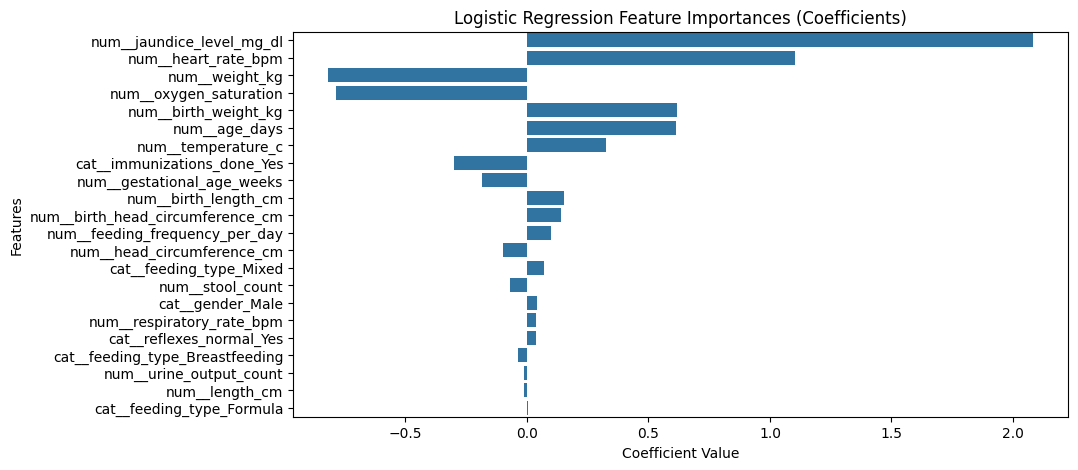

In [9]:
# Get feature importances (coefficients)
feat_imps = clf.coef_[0]  # logistic regression coefficients (1D array)

# Sort by absolute importance (most impactful first)
idx_order = np.argsort(-np.abs(feat_imps))
ordered_imps = np.take_along_axis(feat_imps, idx_order, axis=0)
ordered_labels = np.take_along_axis(np.array(preprocessed_feature_names), idx_order, axis=0)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=ordered_imps, y=ordered_labels)
plt.title("Logistic Regression Feature Importances (Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()

We used feature importance because it provides interpretability for the whole model. This allows medical practitioners to understand which inputs drive a model's prediction and verify that the logic is medically sound based on their expertise. One thing to note is that `Jaundice level` has is the largest positive feature which indicates with higher levels of this feature, the more likely a model predicts "At Risk". This follows for other features such as `Heart rate`, `Birth Weight`, and `Age`. On the other hand, lower `Weight` and lower `Oxygen` likely increases risk due to its negative sign implying an inverse relationship. These are the important features that clinicians could monitor infants closely as they strongly influence the model's prediction of risk. However, using feature importance tends to be model-specific and may be biased toward features that have more unique values which cannot be standardized for all models. 

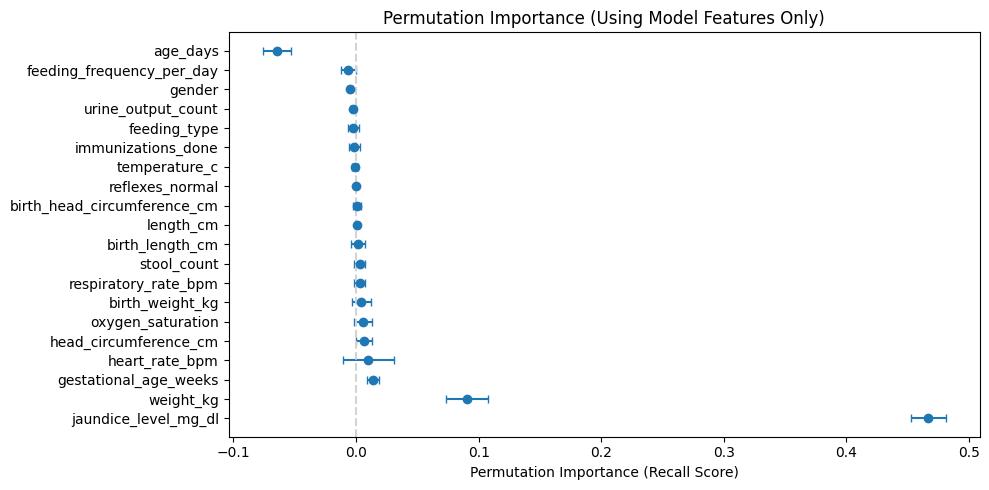

In [10]:
# Keep only the columns the model actually uses
used_columns = [
    "gestational_age_weeks", "birth_weight_kg", "birth_length_cm",
    "birth_head_circumference_cm", "age_days", "weight_kg", "length_cm",
    "head_circumference_cm", "temperature_c", "heart_rate_bpm",
    "respiratory_rate_bpm", "oxygen_saturation", "feeding_frequency_per_day",
    "urine_output_count", "stool_count", "jaundice_level_mg_dl",
    "gender", "feeding_type", "immunizations_done", "reflexes_normal"
]

X = historical_df[used_columns]
y = historical_df[historical_df.columns[-1]].map({"Healthy": 0, "At Risk": 1})

# Compute permutation importance on the pipeline
perm_imp = permutation_importance(
    old_model,
    X,
    y,
    scoring="recall",
    random_state=42,
    n_repeats=5
)

# Use raw column names (not preprocessed ones) for interpretability
FEATURE_NAMES = np.array(X.columns)

# Sort by importance
idx_order = np.argsort(-perm_imp.importances_mean)
ordered_means = perm_imp.importances_mean[idx_order]
ordered_stds = perm_imp.importances_std[idx_order]
ordered_labels = FEATURE_NAMES[idx_order]

# Plot
plt.figure(figsize=(10, 5))
plt.errorbar(
    x=ordered_means,
    y=ordered_labels,
    xerr=ordered_stds,
    fmt="o",
    capsize=3
)
plt.xlabel("Permutation Importance (Recall Score)")
plt.axvline(0, linestyle="--", c="lightgray")
plt.title("Permutation Importance (Using Model Features Only)")
plt.tight_layout()
plt.show()


We used permutation importance to quantify how much each feature affects the model's performance. Given the medical context, recall is a crucial metric because it directly measures the ability of the model to avoid False Negatives which has the highest cost since lives are at risk. The most critical positive predictor is `Jaundice level` with a value of about 0.48. Shuffling it causes an approximate 50% drop in the model's ability to correctly find at-risk infants. This is similar for the next highest positive predictor for `Weight` with a value of approximately 0.1. On the other hand for `Age`, shuffling this feature improves the model's score. This is a strong indication that the model is using age incorrectly as it has a higher tendency to create false negative errors. 

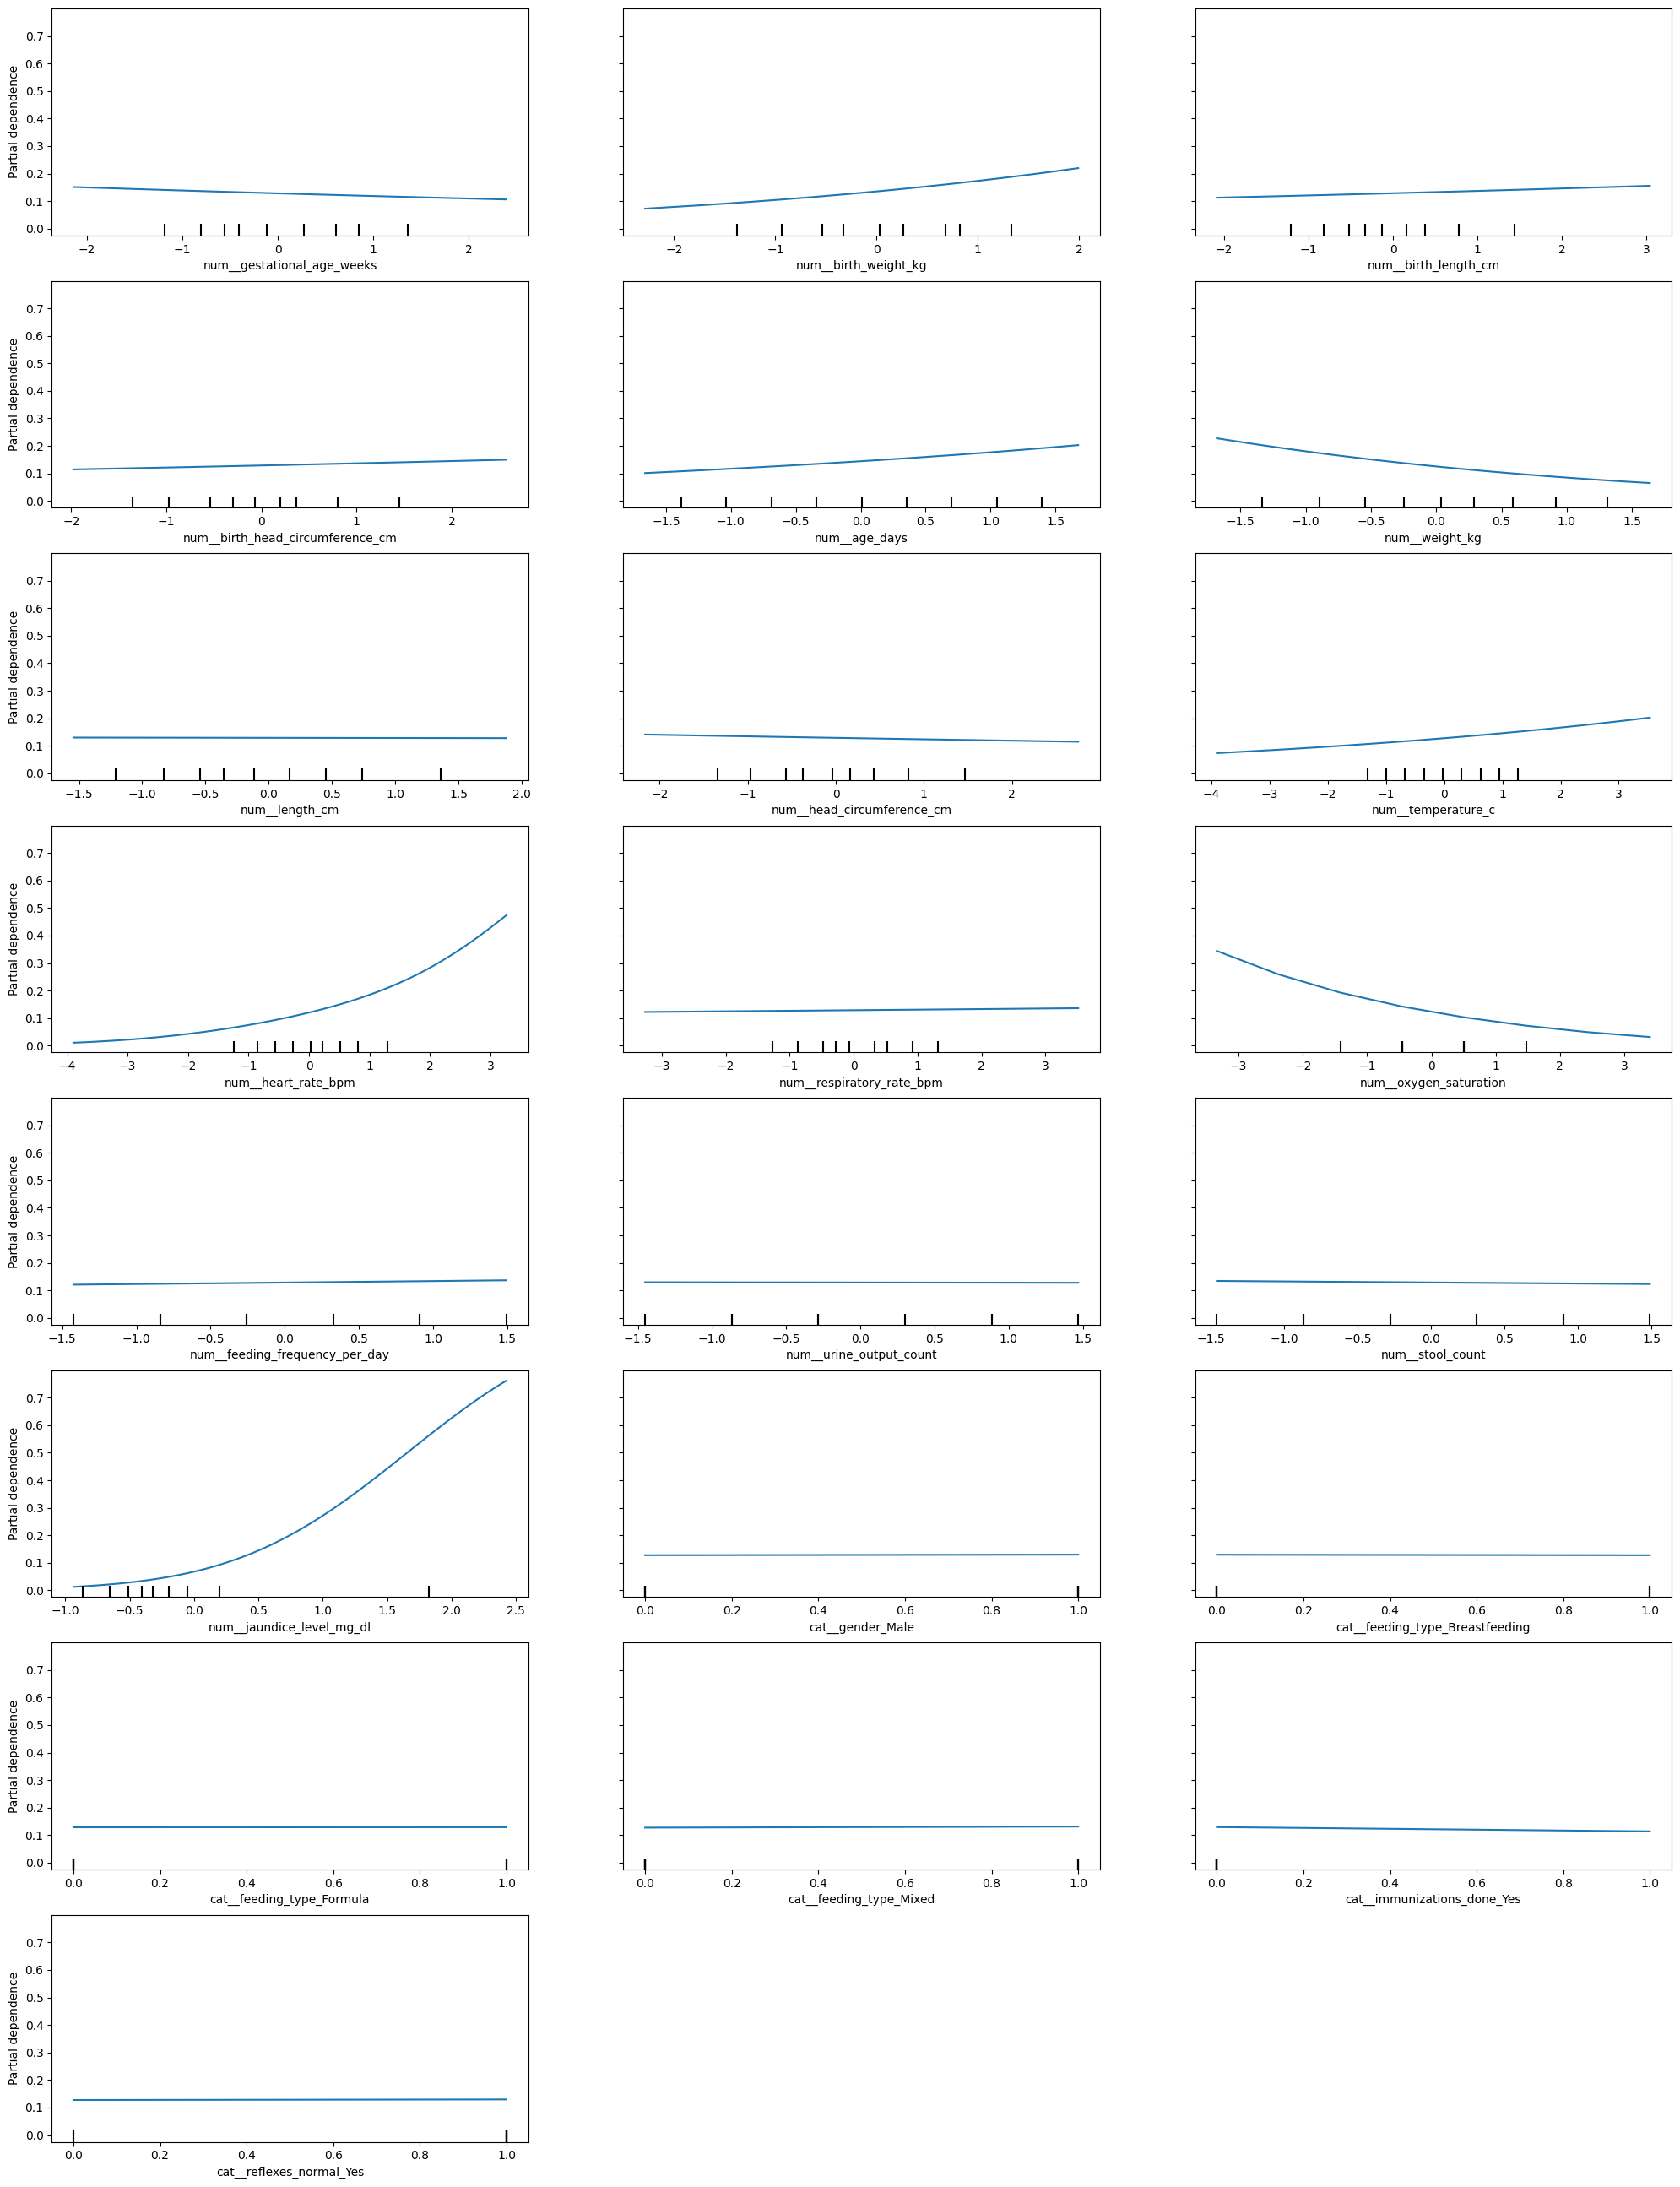

In [ ]:
X_preprocessed_only = old_model['preprocess'].transform(X)

# Now run your PDP code again
fig, ax = plt.subplots(figsize=(20, 26))
disp = PartialDependenceDisplay.from_estimator(
    clf,
    X_preprocessed_only,
    np.arange(X_preprocessed_only.shape[1]),
    feature_names=old_model['preprocess'].get_feature_names_out() ,
    ax=ax
)
plt.tight_layout()
plt.show()


We also used partial depdenence plots (PDP) to help understand the functional relationships between a feature and a prediction. It helps provide clinical context and helps validate the model's structure by providing the average effect of a feature on the prediction, isolating that feature from all others. The steepest slope in the PDP for `Jaundice level` and `Heart Rate` indicates that for a small increase of this feature, there is a high increase in predicted probability that an infant is classified as "At Risk." On the other hand, `Oxygen` and `Weight` have a steep decreasing slope, meaning that as this feature increases, the predicted probability of the infant being classified as "At Risk" decreases rapidly. 

  0%|          | 0/100 [00:00<?, ?it/s]

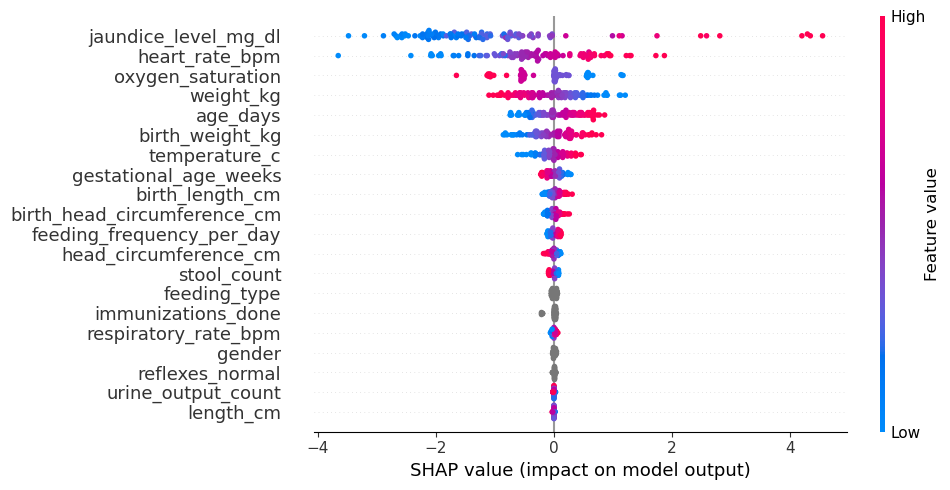

In [ ]:
import shap
import pandas as pd

# Use the same X from permutation importance (raw features)
X_for_shap = X.copy()

# Wrap model function to keep DataFrame structure
model_fn = lambda x: old_model.predict_proba(
    pd.DataFrame(x, columns=X_for_shap.columns)
)

# Create KernelExplainer
shap_explainer = shap.KernelExplainer(
    model=model_fn,
    data=shap.sample(X_for_shap, 100, random_state=42),
    feature_names=X_for_shap.columns,
    link="logit"  # since we're predicting probabilities
)

# Compute SHAP values (on a sample for speed)
X_sample = shap.sample(X_for_shap, 100, random_state=42)
shap_values = shap_explainer.shap_values(X_sample)

# Select the class index you want to explain (1 = "At Risk")
class_idx = 1

# Summary plot (same format as your old code)
shap.summary_plot(
    shap_values[:, :, class_idx],
    X_sample,
    plot_size=(10, 5)
)


Lastly, we used Global SHAP because it aggregates the individual feature contributions to visually summarize how the model works overall across all infants. This aggregated view allows medical practitioners to quickly confirm the model's logic aligns with general clinical knowledge. `Jaundice level`, followed by `Heart Rate` are the most critical risk factors. The red dots have the strongest positive impact on the model's output, pushing prediction heavily toward 'At Risk' with a value of around 4.5. On the other hand, low values of `Oxygen Saturation` and `Weight` is a major risk factor as the blue dots (low values) push the prediction toward 'At Risk'. 

# H-Statistic

It quantifies the overall interaction strength between features across the entire dataset, so it helps understand the structure of the model and how features interact to shape the prediction function in general.